In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.cm

In [5]:
mnist = fetch_openml('mnist_784', version=1)
x, y = mnist['data'], mnist['target']

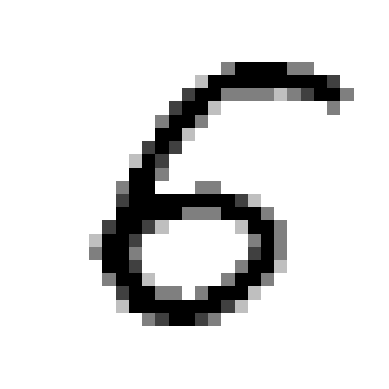

In [ ]:
# Visualize one example
some_digit = x.to_numpy()[31000]# [31000] is value for 6 and it can be change for diff number
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
plt.axis("off")
plt.show()


In [12]:
print("Label of shown image:", y[31000])


Label of shown image: 6


In [14]:
# Train-test split
x_train, x_test = x[:60000], x[60000:]
y_train, y_test = y[:60000], y[60000:]

# Shuffle training data
shuffled_index = np.random.permutation(60000)
x_train = x_train.iloc[shuffled_index]
y_train = y_train.iloc[shuffled_index]

##creating a 6 detector


In [19]:

# Convert to integer labels
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)

# Create binary labels for detecting "3"
y_train_6 = (y_train == 6)
y_test_6 = (y_test == 6)


In [20]:
# Train a Random Forest classifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(x_train, y_train_6)



RandomForestClassifier(random_state=42)

In [21]:
# Predict on a sample digit
val = forest_clf.predict([some_digit])
print("Is it a 6?", val)

Is it a 6? [ True]


C:\Users\Shashank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
# Evaluate using cross-validation
rf_scores = cross_val_score(forest_clf, x_train, y_train_6, cv=6, scoring='accuracy')
print("Random Forest Mean Accuracy:", rf_scores.mean())


Random Forest Mean Accuracy: 0.9935833333333334
